In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict
from Bio.Align import PairwiseAligner, substitution_matrices
from scipy.cluster.hierarchy import fcluster, linkage as sp_linkage
from scipy.spatial.distance import squareform

# Cross-reactivity clustering for PhIP-Seq hit peptides. 

## Pipeline: 
1. seed candidate pairs with reduced-alphabet k-mers (conservative substitution still matches)
2. score each candidate pair with BLOSUM62 Smith-Waterman. 
3. threshold + union-find into clusters

In [84]:
meta = pd.read_csv('lassa_library_sequences_species_standardized_070726_ICTV_corrected.csv')
df = pd.read_csv('long_091826.csv')
hits = pd.read_csv('pep_hits_wo_taxa_to_remove_091826.csv').set_index('peptide')

In [85]:
hits = hits.drop(columns='Unnamed: 0')

In [86]:
sequences = hits['sequence'].to_dict() #this keeps the peptide index
print(len(hits), "hit peptides") 

1287 hit peptides


In [87]:
BLOSUM62 = substitution_matrices.load("BLOSUM62")

def make_aligner():
    aln = PairwiseAligner()
    aln.mode = 'local'
    aln.substitution_matrix = BLOSUM62
    aln.open_gap_score = -10
    aln.extend_gap_score = -0.5
    return aln

def similarity_matrix(sequences, progress_every=200):
    idx     = list(sequences)
    aligner = make_aligner()
    seqs    = [str(sequences[i]).upper() for i in idx]
    selfs   = [aligner.score(s, s) for s in seqs]
    n, mat  = len(idx), np.eye(len(idx))
    for i in range(n):
        for j in range(i + 1, n):
            d = min(selfs[i], selfs[j])
            mat[i, j] = mat[j, i] = aligner.score(seqs[i], seqs[j]) / d if d else 0.0
        if progress_every and (i + 1) % progress_every == 0:
            print(f"  aligned {i+1}/{n} rows")
    return idx, mat

In [88]:
idx, mat = similarity_matrix(sequences)

  aligned 200/1287 rows
  aligned 400/1287 rows
  aligned 600/1287 rows
  aligned 800/1287 rows
  aligned 1000/1287 rows
  aligned 1200/1287 rows


In [89]:
THRESHOLD = 0.5

def collapse(idx, mat, threshold=0.5):
    dist = 1.0 - mat
    np.fill_diagonal(dist, 0.0)
    Z    = sp_linkage(squareform(dist, checks=False), method='average')
    flat = fcluster(Z, t=1.0 - threshold, criterion='distance')
    labels = {pid: int(c) for pid, c in zip(idx, flat)}
    n_cl = len(set(flat))
    print(f"{len(idx)} peptides -> {n_cl} clusters ({len(idx)/n_cl:.2f}x collapse)")
    return labels

labels = collapse(idx, mat, threshold=THRESHOLD)
hits['cluster'] = hits.index.map(labels)

1287 peptides -> 945 clusters (1.36x collapse)


In [90]:
def describe_collapse(hits, labels):
    h = hits.copy()
    h['cluster'] = h.index.map(labels)
    sizes = h.groupby('cluster').size()
    rows = []
    for cid, grp in h[h.cluster.isin(sizes[sizes > 1].index)].groupby('cluster'):
        n_fam, n_gen, n_sp, n_acc = (grp[c].nunique()
                                     for c in ['family','genus','species','accession'])
        kind = ('cross_family'   if n_fam > 1 else
                'cross_genus'    if n_gen > 1 else
                'cross_species'  if n_sp  > 1 else
                'within_species' if n_acc > 1 else 'same_protein')
        rows.append({'cluster': cid, 'n_peptides': len(grp), 'kind': kind,
                     'species_list': ';'.join(sorted(set(grp.species))[:4])})
    out = pd.DataFrame(rows)
    if len(out):
        print(out['kind'].value_counts().to_string())
        return out.sort_values('n_peptides', ascending=False).reset_index(drop=True)
    return out

desc = describe_collapse(hits, labels)
desc.head(20)

kind
cross_species     123
within_species     48
same_protein       14
cross_genus        12


,cluster,n_peptides,kind,species_list
0,99,13,cross_genus,Arenavirus sp.;Erinaceus europaeus arenavirus;...
1,454,10,cross_species,Nairoviridae sp.;Orthonairovirus bushkeyense;O...
2,131,9,cross_species,Huangpi virus;Kilimanjaro virus;Limestone Cany...
3,565,9,cross_species,Mammarenavirus bituense;Mammarenavirus kwanzae...
4,212,8,cross_species,Mammarenavirus kwanzaense;Mammarenavirus lassa...
5,310,7,cross_species,Orthohantavirus andesense;Orthohantavirus bayo...
6,564,7,within_species,Mammarenavirus lassaense
7,276,7,cross_genus,Mammarenavirus lassaense;Mammarenavirus lunaen...
8,642,7,cross_species,Mammarenavirus brazilense;Mammarenavirus pirit...
9,130,6,cross_species,Phlebovirus candiruense;Phlebovirus cocleense;...


In [91]:
def epitope_breadth(df, labels, reactive_col='reactive'):
    r = df[df[reactive_col]].copy()
    r['cluster'] = r['peptide'].map(labels)
    g = r.groupby('individual')
    out = pd.DataFrame({
        'n_reactive_peptides': g['peptide'].nunique(),
        'n_epitope_clusters':  g['cluster'].nunique(),
        'n_species_apparent':  g['species'].nunique(),
    })
    out['inflation'] = out.n_reactive_peptides / out.n_epitope_clusters.replace(0, np.nan)
    meta_i = df.drop_duplicates('individual').set_index('individual')
    for c in ('cohort', 'category'):
        if c in meta_i.columns:
            out[c] = meta_i[c]
    return out

breadth = epitope_breadth(df, labels)
print(breadth.groupby('cohort')[['n_reactive_peptides','n_epitope_clusters',
                                 'n_species_apparent','inflation']].mean().round(2))

        n_reactive_peptides  n_epitope_clusters  n_species_apparent  inflation
cohort                                                                        
SL                    114.0              100.61               86.06       1.13


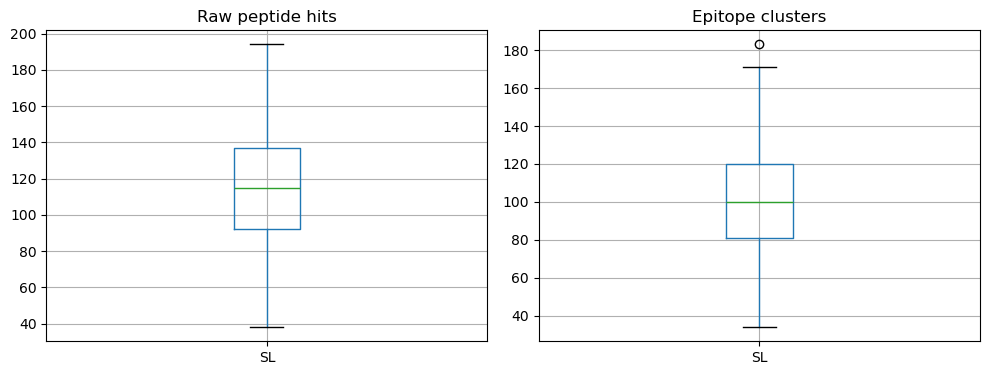

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))
for ax, col, title in zip(axes, ['n_reactive_peptides','n_epitope_clusters'],
                          ['Raw peptide hits','Epitope clusters']):
    breadth.boxplot(column=col, by='cohort', ax=ax)
    ax.set_title(title); ax.set_xlabel('')
plt.suptitle(''); plt.tight_layout()